# Hierarchical Facility Location Problem
## SA vs GA vs ILP Comparison

This notebook compares three approaches for the **two-level, globally-inclusive, nested HFLP**:

1. **Simulated Annealing (SA)** – Metropolis-criterion metaheuristic.
2. **Genetic Algorithm (GA)** – population-based evolutionary metaheuristic.
3. **Integer Linear Programming (ILP)** – exact CBC/PuLP solver (used as baseline on small instances).

All algorithms and the problem definition live in `hflp_algorithms.py`.

### Problem Formulation

Following Daskin (1995) and Şahin & Süral (2007), we consider a **two-level, globally-inclusive, nested** HFLP.

**Sets:**
- $I$: demand nodes  
- $J = J'$: candidate sites for Level-1 and Level-2 facilities

**Parameters:**
- $h_i$: demand at node $i$  
- $d_{ij}$: shortest-path distance from demand node $i$ to candidate $j$  
- $p_1, p_2$: number of level-1 and level-2 facilities to open  $(p_2 \le p_1)$

**Objective** (minimize total demand-weighted travel):
$$\min \sum_i \sum_j h_i \, d_{ij} \, Y_{ij} + \sum_i \sum_{j'} h_i \, d_{ij'} \, X_{ij'}$$

with nesting constraint $x_{j'} \le y_{j'}$ (every L2 site must also be open as an L1 site).

---
**References:**  
- Şahin & Süral (2007). *A review of hierarchical facility location models.* C&OR.  
- Farahani et al. (2014). *Hierarchical facility location problem.* C&IE.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from hflp_algorithms import (
    make_random_graph,
    make_grid_graph,
    make_hflp_instance,
    eval_solution,
    simulated_annealing_hflp,
    solve_hflp_ilp,
    genetic_algorithm_hflp,
    plot_solution,
    plot_convergence_history,
    compare_bar,
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)
random.seed(42)

print('All imports OK')

All imports OK


---
## 1. Experiment A: Small Random Graph (20 nodes)

Erdős–Rényi graph, $n=20$, $p_{\text{edge}}=0.3$, Euclidean weights.  
Open $p_1=5$ Level-1 and $p_2=2$ Level-2 facilities.  
The ILP gives the exact optimum on this size.

In [2]:
G_small = make_random_graph(n=20, p=0.3, seed=42)
inst_small = make_hflp_instance(G_small, p1=5, p2=2)

print(f'Graph : {G_small.number_of_nodes()} nodes, {G_small.number_of_edges()} edges')
print(f'p1={inst_small["p1"]}, p2={inst_small["p2"]}')
print(f'Demand: {inst_small["demand"]}')

Graph : 20 nodes, 53 edges
p1=5, p2=2
Demand: [5. 7. 4. 4. 8. 8. 8. 9. 9. 8. 7. 5. 1. 8. 1. 8. 7. 4. 6. 9.]


### 1.1 Simulated Annealing

In [3]:
print('Running SA ...')
t0 = time.time()
sa_lv1_s, sa_lv2_s, sa_cost_s, sa_hist_s = simulated_annealing_hflp(
    inst_small,
    T_init=300.0, alpha=0.997, max_iter=5_000, seed=0, verbose=True
)
sa_time_s = time.time() - t0

print(f'\nSA  best cost : {sa_cost_s:.4f}  ({sa_time_s:.2f}s)')
print(f'    L1 open   : {sorted(sa_lv1_s)}')
print(f'    L2 open   : {sorted(sa_lv2_s)}')

Running SA ...
  iter    500 | T=66.7883 | cur=100.89 | best=84.36
  iter   1000 | T=14.8689 | cur=93.60 | best=84.36
  iter   1500 | T=3.3102 | cur=92.53 | best=83.68
  iter   2000 | T=0.7369 | cur=84.79 | best=82.94
  iter   2500 | T=0.1641 | cur=82.50 | best=82.50
  iter   3000 | T=0.0365 | cur=81.97 | best=81.97
  iter   3500 | T=0.0081 | cur=81.97 | best=81.97
  iter   4000 | T=0.0018 | cur=81.97 | best=81.97
  iter   4500 | T=0.0010 | cur=81.97 | best=81.97
  iter   5000 | T=0.0010 | cur=81.97 | best=81.97

SA  best cost : 81.9672  (0.25s)
    L1 open   : [4, 6, 7, 13, 14]
    L2 open   : [6, 14]


### 1.2 Genetic Algorithm

In [4]:
print('Running GA ...')
t0 = time.time()
ga_lv1_s, ga_lv2_s, ga_cost_s, ga_hist_s = genetic_algorithm_hflp(
    inst_small,
    pop_size=60, max_gen=300,
    tournament_k=3, crossover_prob=0.8, mutation_rate=0.3,
    elitism=True, seed=0, verbose=True
)
ga_time_s = time.time() - t0

print(f'\nGA  best cost : {ga_cost_s:.4f}  ({ga_time_s:.2f}s)')
print(f'    L1 open   : {sorted(ga_lv1_s)}')
print(f'    L2 open   : {sorted(ga_lv2_s)}')

Running GA ...
  gen    30 | best=81.97 | avg=101.49
  gen    60 | best=81.97 | avg=90.91
  gen    90 | best=81.97 | avg=92.81
  gen   120 | best=81.97 | avg=88.09
  gen   150 | best=81.97 | avg=93.14
  gen   180 | best=81.97 | avg=88.90
  gen   210 | best=81.97 | avg=93.10
  gen   240 | best=81.97 | avg=92.08
  gen   270 | best=81.97 | avg=93.10
  gen   300 | best=81.97 | avg=90.72

GA  best cost : 81.9672  (0.85s)
    L1 open   : [4, 6, 7, 13, 14]
    L2 open   : [6, 14]


### 1.3 ILP (exact)

In [5]:
print('Running ILP ...')
t0 = time.time()
ilp_lv1_s, ilp_lv2_s, ilp_cost_s, ilp_time_s, ilp_status_s = solve_hflp_ilp(inst_small)
ilp_time_s = time.time() - t0

print(f'\nILP status    : {ilp_status_s}')
print(f'ILP best cost : {ilp_cost_s:.4f}  ({ilp_time_s:.2f}s)')
print(f'    L1 open   : {sorted(ilp_lv1_s)}')
print(f'    L2 open   : {sorted(ilp_lv2_s)}')

print(f'\nOptimality gap – SA : {100*(sa_cost_s - ilp_cost_s)/ilp_cost_s:.2f}%')
print(f'Optimality gap – GA : {100*(ga_cost_s - ilp_cost_s)/ilp_cost_s:.2f}%')

Running ILP ...

ILP status    : Optimal
ILP best cost : 81.9672  (0.08s)
    L1 open   : [4, 6, 7, 13, 14]
    L2 open   : [6, 14]

Optimality gap – SA : 0.00%
Optimality gap – GA : 0.00%


### 1.4 Convergence Comparison

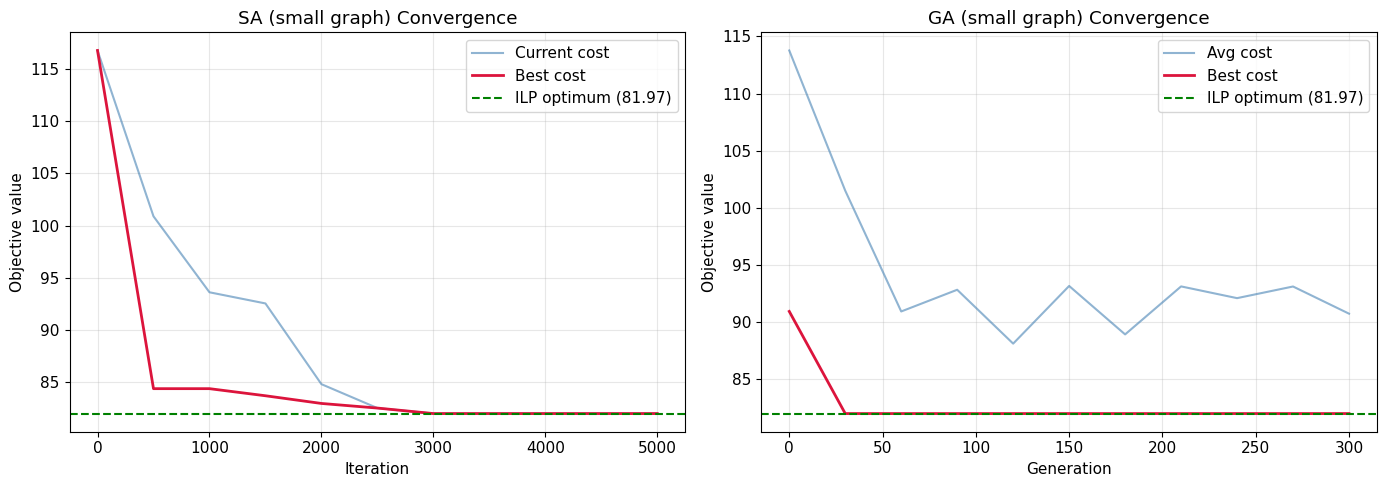

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_convergence_history(sa_hist_s, algo_name='SA (small graph)', ax=axes[0])
# draw ILP optimum as a horizontal reference line
axes[0].axhline(ilp_cost_s, color='green', lw=1.5, ls='--', label=f'ILP optimum ({ilp_cost_s:.2f})')
axes[0].legend()

plot_convergence_history(ga_hist_s, algo_name='GA (small graph)', ax=axes[1])
axes[1].axhline(ilp_cost_s, color='green', lw=1.5, ls='--', label=f'ILP optimum ({ilp_cost_s:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.5 Solution Visualisation

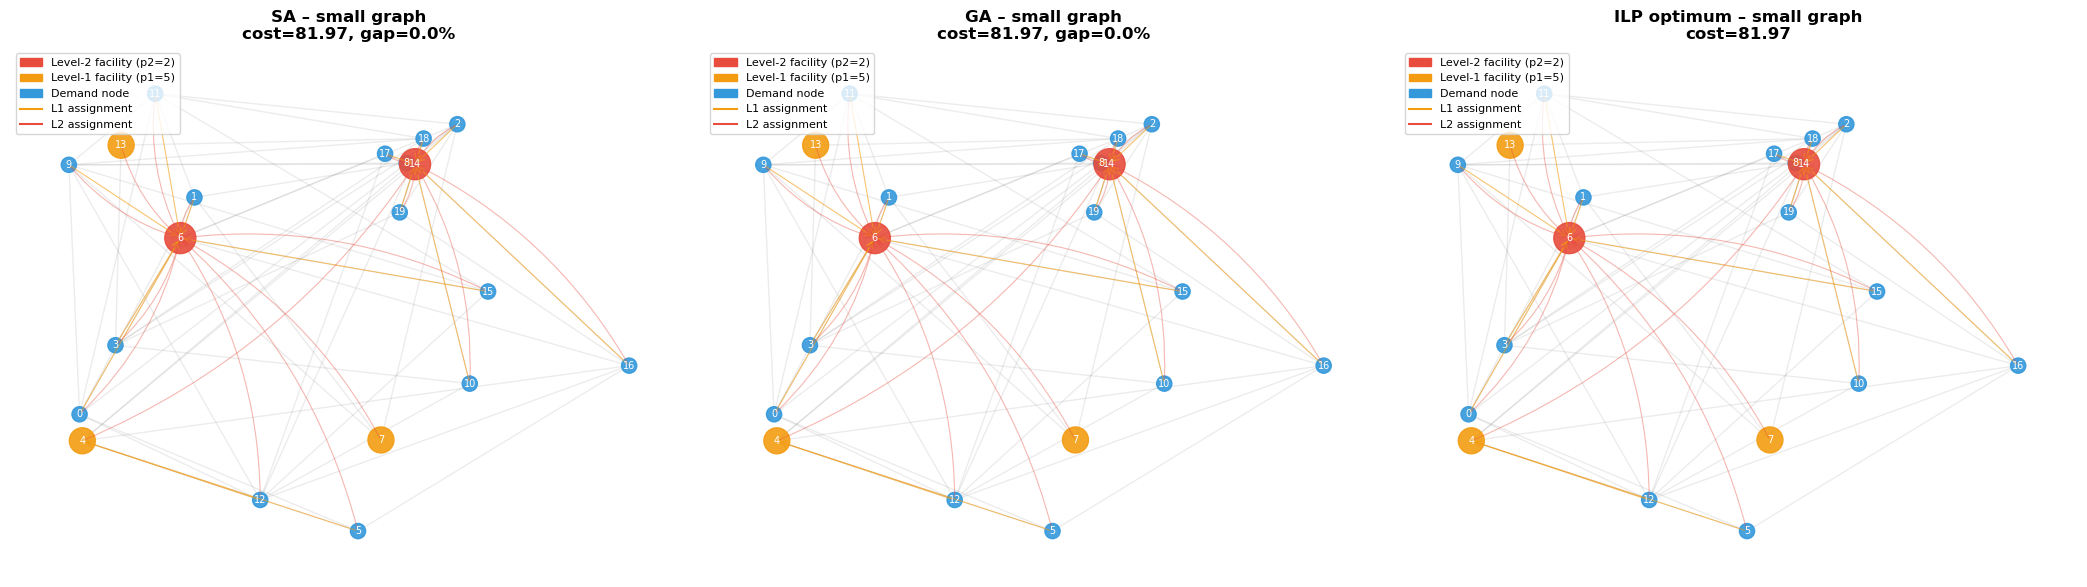

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
gap_sa = 100*(sa_cost_s - ilp_cost_s)/ilp_cost_s
gap_ga = 100*(ga_cost_s - ilp_cost_s)/ilp_cost_s

plot_solution(inst_small, sa_lv1_s, sa_lv2_s,
              title=f'SA – small graph\ncost={sa_cost_s:.2f}, gap={gap_sa:.1f}%', ax=axes[0])
plot_solution(inst_small, ga_lv1_s, ga_lv2_s,
              title=f'GA – small graph\ncost={ga_cost_s:.2f}, gap={gap_ga:.1f}%', ax=axes[1])
plot_solution(inst_small, ilp_lv1_s, ilp_lv2_s,
              title=f'ILP optimum – small graph\ncost={ilp_cost_s:.2f}', ax=axes[2])
plt.tight_layout()
plt.show()

### 1.6 Summary Bar Chart

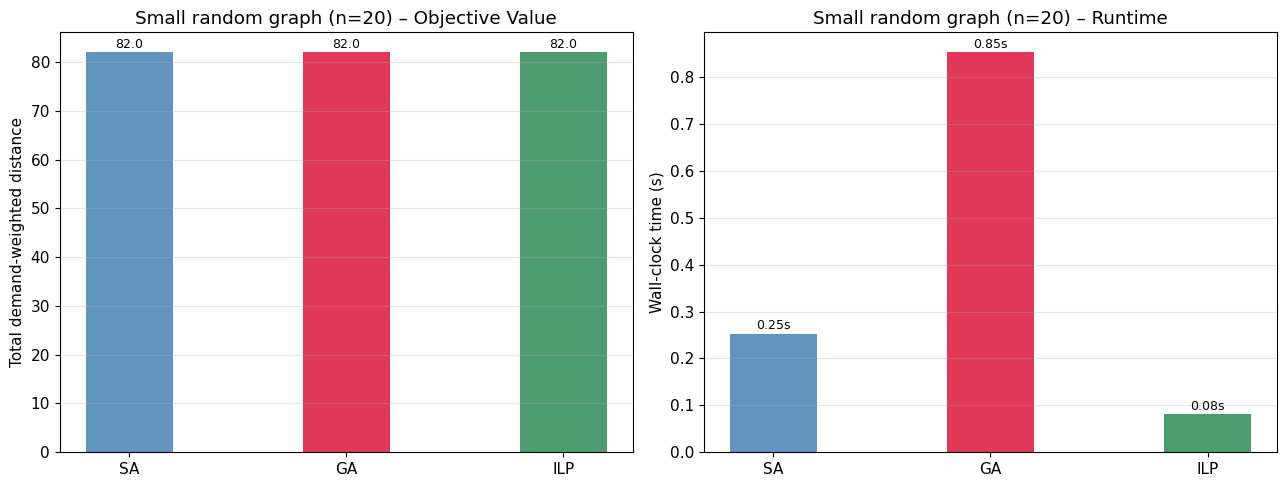

In [8]:
compare_bar(
    {
        'SA':  {'cost': sa_cost_s,  'time': sa_time_s},
        'GA':  {'cost': ga_cost_s,  'time': ga_time_s},
        'ILP': {'cost': ilp_cost_s, 'time': ilp_time_s},
    },
    title='Small random graph (n=20)'
)

---
## 2. Experiment B: Medium Random Graph (50 nodes)

Erdős–Rényi graph, $n=50$, $p_{\text{edge}}=0.2$, Euclidean weights.  
Open $p_1=8$ Level-1 and $p_2=3$ Level-2 facilities.  
ILP is run with a 60-second time limit to get a reference bound.

In [33]:
n_med = 400
G_med = make_random_graph(n=n_med, p=0.2, seed=123)
inst_med = make_hflp_instance(G_med, p1=8, p2=3, demand_seed=99)

print(f'Graph : {G_med.number_of_nodes()} nodes, {G_med.number_of_edges()} edges')
print(f'p1={inst_med["p1"]}, p2={inst_med["p2"]}')

Graph : 400 nodes, 15976 edges
p1=8, p2=3


In [34]:
print('Running SA ...')
t0 = time.time()
sa_lv1_m, sa_lv2_m, sa_cost_m, sa_hist_m = simulated_annealing_hflp(
    inst_med,
    T_init=500.0, alpha=0.9999, max_iter=15_000, seed=0, verbose=True
)
sa_time_m = time.time() - t0
print(f'\nSA  best cost : {sa_cost_m:.4f}  ({sa_time_m:.2f}s)')

Running SA ...
  iter   1500 | T=430.3508 | cur=1024.19 | best=1000.56
  iter   3000 | T=370.4036 | cur=1122.50 | best=980.53
  iter   4500 | T=318.8069 | cur=1188.99 | best=980.53
  iter   6000 | T=274.3976 | cur=1054.60 | best=980.53
  iter   7500 | T=236.1744 | cur=1212.37 | best=980.53
  iter   9000 | T=203.2757 | cur=1148.69 | best=975.80
  iter  10500 | T=174.9597 | cur=1099.81 | best=975.80
  iter  12000 | T=150.5881 | cur=1058.56 | best=975.80
  iter  13500 | T=129.6114 | cur=1083.80 | best=975.80
  iter  15000 | T=111.5567 | cur=1182.02 | best=975.80

SA  best cost : 975.7984  (16.91s)


In [35]:
print('Running GA ...')
t0 = time.time()
ga_lv1_m, ga_lv2_m, ga_cost_m, ga_hist_m = genetic_algorithm_hflp(
    inst_med,
    pop_size=80, max_gen=500,
    tournament_k=5, crossover_prob=0.8, mutation_rate=0.35,
    elitism=True, seed=0, verbose=True
)
ga_time_m = time.time() - t0
print(f'\nGA  best cost : {ga_cost_m:.4f}  ({ga_time_m:.2f}s)')

Running GA ...
  gen    50 | best=906.59 | avg=957.22
  gen   100 | best=891.89 | avg=932.92
  gen   150 | best=889.09 | avg=956.44
  gen   200 | best=885.91 | avg=974.62
  gen   250 | best=885.60 | avg=955.63
  gen   300 | best=885.60 | avg=951.98
  gen   350 | best=884.93 | avg=942.11
  gen   400 | best=883.76 | avg=946.02
  gen   450 | best=883.29 | avg=963.29
  gen   500 | best=883.29 | avg=930.25

GA  best cost : 883.2919  (41.07s)


In [28]:
print('Running ILP (60s limit) ...')
t0 = time.time()
ilp_lv1_m, ilp_lv2_m, ilp_cost_m, ilp_time_m, ilp_status_m = solve_hflp_ilp(
    inst_med, time_limit=60
)
ilp_time_m = time.time() - t0
print(f'ILP status    : {ilp_status_m}')
print(f'ILP best cost : {ilp_cost_m:.4f}  ({ilp_time_m:.2f}s)')
print(f'\nOptimality gap – SA : {100*(sa_cost_m - ilp_cost_m)/ilp_cost_m:.2f}%')
print(f'Optimality gap – GA : {100*(ga_cost_m - ilp_cost_m)/ilp_cost_m:.2f}%')

Running ILP (60s limit) ...
ILP status    : Not Solved
ILP best cost : inf  (148.04s)

Optimality gap – SA : nan%
Optimality gap – GA : nan%


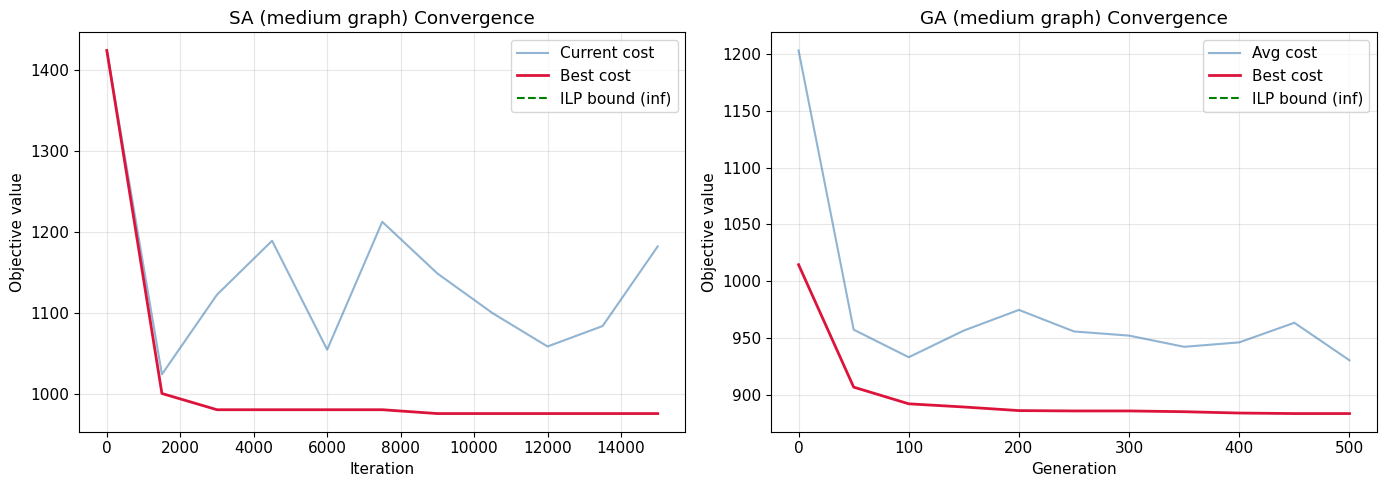

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_convergence_history(sa_hist_m, algo_name='SA (medium graph)', ax=axes[0])
axes[0].axhline(ilp_cost_m, color='green', lw=1.5, ls='--', label=f'ILP bound ({ilp_cost_m:.2f})')
axes[0].legend()

plot_convergence_history(ga_hist_m, algo_name='GA (medium graph)', ax=axes[1])
axes[1].axhline(ilp_cost_m, color='green', lw=1.5, ls='--', label=f'ILP bound ({ilp_cost_m:.2f})')
axes[1].legend()

plt.tight_layout()
plt.show()

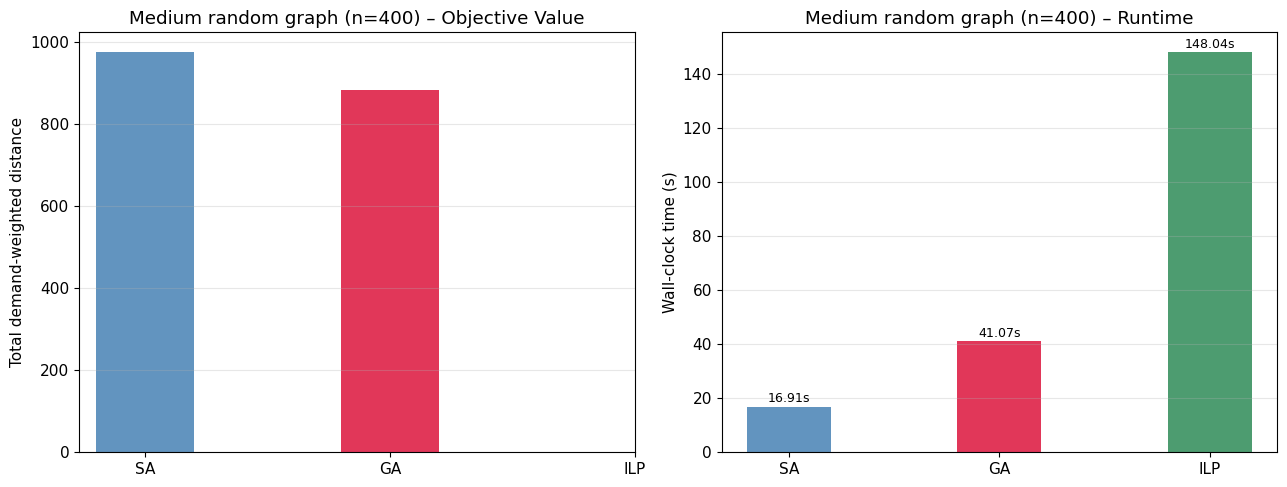

In [37]:
compare_bar(
    {
        'SA':  {'cost': sa_cost_m,  'time': sa_time_m},
        'GA':  {'cost': ga_cost_m,  'time': ga_time_m},
        'ILP': {'cost': ilp_cost_m, 'time': ilp_time_m},
    },
    title=f'Medium random graph (n={n_med})'
)

---
## 3. Experiment C: Grid Graph (20×20 = 400 nodes)

A 20×20 grid (400 nodes, unit edge weights).  
Open $p_1=5$ Level-1 and $p_2=2$ Level-2 facilities.  
ILP is intractable at this scale; SA and GA are compared directly.

In [15]:
G_grid = make_grid_graph(20, 20)
inst_grid = make_hflp_instance(G_grid, p1=5, p2=2)

print(f'Grid graph : {G_grid.number_of_nodes()} nodes, {G_grid.number_of_edges()} edges')
print(f'p1={inst_grid["p1"]}, p2={inst_grid["p2"]}')

Grid graph : 400 nodes, 760 edges
p1=5, p2=2


In [16]:
print('Running SA on grid ...')
t0 = time.time()
sa_lv1_g, sa_lv2_g, sa_cost_g, sa_hist_g = simulated_annealing_hflp(
    inst_grid,
    T_init=400.0, alpha=0.999, max_iter=10_000, seed=0, verbose=True
)
sa_time_g = time.time() - t0
print(f'\nSA  best cost : {sa_cost_g:.4f}  ({sa_time_g:.2f}s)')
print(f'    L1 open   : {sorted(sa_lv1_g)}')
print(f'    L2 open   : {sorted(sa_lv2_g)}')

Running SA on grid ...
  iter   1000 | T=147.0782 | cur=25527.00 | best=24942.00
  iter   2000 | T=54.0800 | cur=24974.00 | best=24929.00
  iter   3000 | T=19.8850 | cur=24586.00 | best=24586.00
  iter   4000 | T=7.3116 | cur=24467.00 | best=24467.00
  iter   5000 | T=2.6884 | cur=24469.00 | best=24467.00
  iter   6000 | T=0.9885 | cur=24471.00 | best=24467.00
  iter   7000 | T=0.3635 | cur=24444.00 | best=24444.00
  iter   8000 | T=0.1336 | cur=24441.00 | best=24441.00
  iter   9000 | T=0.0491 | cur=24384.00 | best=24384.00
  iter  10000 | T=0.0181 | cur=24382.00 | best=24382.00

SA  best cost : 24382.0000  (8.31s)
    L1 open   : [64, 96, 185, 255, 345]
    L2 open   : [185, 255]


In [17]:
print('Running GA on grid ...')
t0 = time.time()
ga_lv1_g, ga_lv2_g, ga_cost_g, ga_hist_g = genetic_algorithm_hflp(
    inst_grid,
    pop_size=100, max_gen=400,
    tournament_k=5, crossover_prob=0.8, mutation_rate=0.4,
    elitism=True, seed=0, verbose=True
)
ga_time_g = time.time() - t0
print(f'\nGA  best cost : {ga_cost_g:.4f}  ({ga_time_g:.2f}s)')
print(f'    L1 open   : {sorted(ga_lv1_g)}')
print(f'    L2 open   : {sorted(ga_lv2_g)}')

Running GA on grid ...
  gen    40 | best=24121.00 | avg=27566.03
  gen    80 | best=24080.00 | avg=26391.43
  gen   120 | best=24049.00 | avg=26606.51
  gen   160 | best=24049.00 | avg=27243.41
  gen   200 | best=24039.00 | avg=26781.83
  gen   240 | best=24019.00 | avg=26375.60
  gen   280 | best=24019.00 | avg=26348.37
  gen   320 | best=24006.00 | avg=26688.28
  gen   360 | best=24006.00 | avg=26370.09
  gen   400 | best=24006.00 | avg=26186.79

GA  best cost : 24006.0000  (35.20s)
    L1 open   : [83, 97, 111, 306, 315]
    L2 open   : [111, 306]


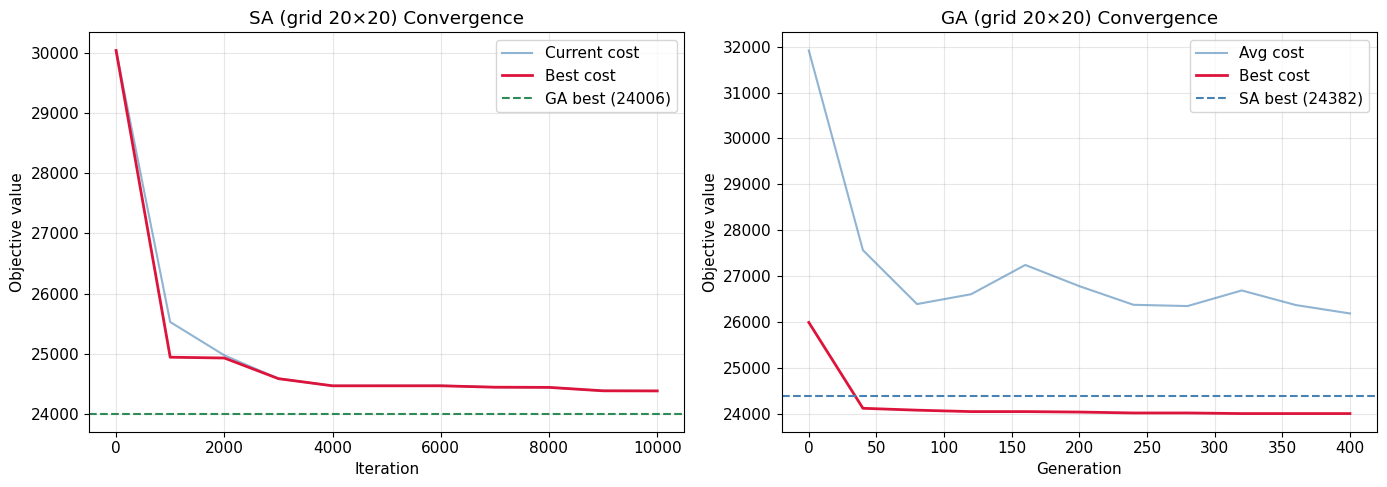

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_convergence_history(sa_hist_g, algo_name='SA (grid 20×20)', ax=axes[0])
plot_convergence_history(ga_hist_g, algo_name='GA (grid 20×20)', ax=axes[1])

# Draw the other algorithm's best as a reference
axes[0].axhline(ga_cost_g, color='seagreen', lw=1.5, ls='--', label=f'GA best ({ga_cost_g:.0f})')
axes[0].legend()
axes[1].axhline(sa_cost_g, color='steelblue', lw=1.5, ls='--', label=f'SA best ({sa_cost_g:.0f})')
axes[1].legend()

plt.tight_layout()
plt.show()

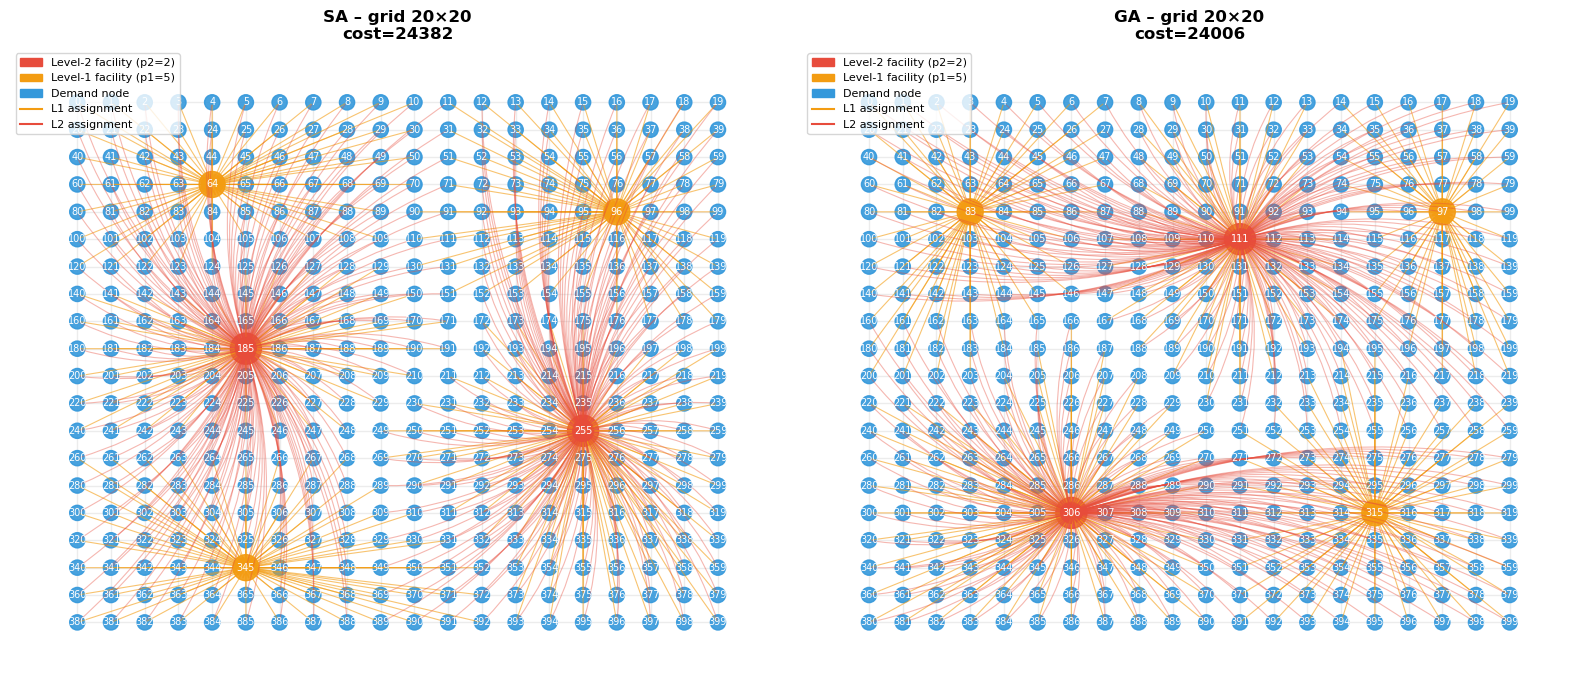

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_solution(inst_grid, sa_lv1_g, sa_lv2_g,
              title=f'SA – grid 20×20\ncost={sa_cost_g:.0f}', ax=axes[0])
plot_solution(inst_grid, ga_lv1_g, ga_lv2_g,
              title=f'GA – grid 20×20\ncost={ga_cost_g:.0f}', ax=axes[1])
plt.tight_layout()
plt.show()

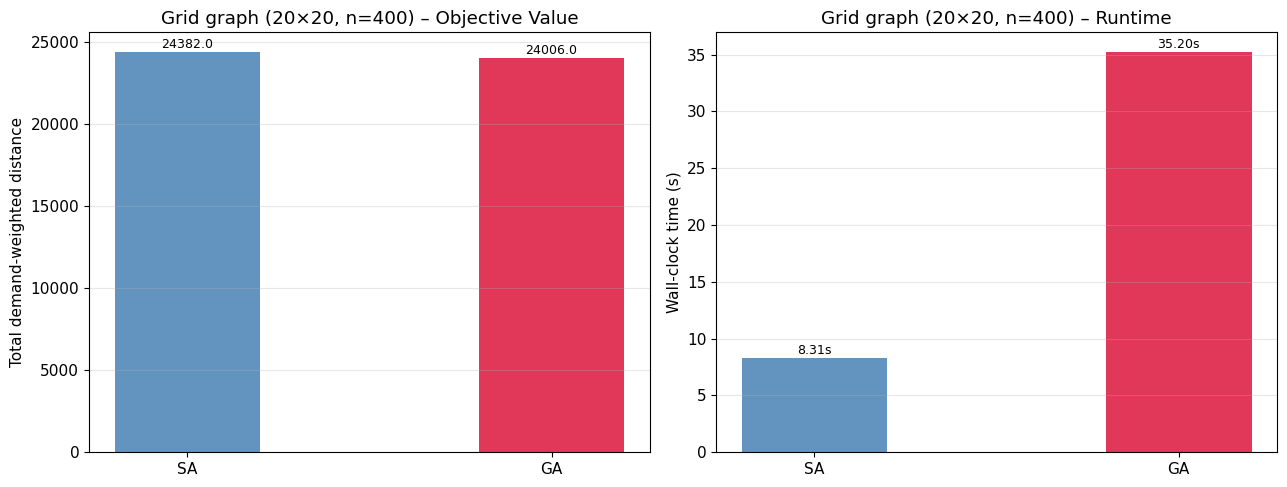

In [20]:
compare_bar(
    {
        'SA': {'cost': sa_cost_g, 'time': sa_time_g},
        'GA': {'cost': ga_cost_g, 'time': ga_time_g},
    },
    title='Grid graph (20×20, n=400)'
)

---
## 4. GA Hyperparameter Sensitivity (small graph)

We vary population size and number of generations to see how the GA scales.

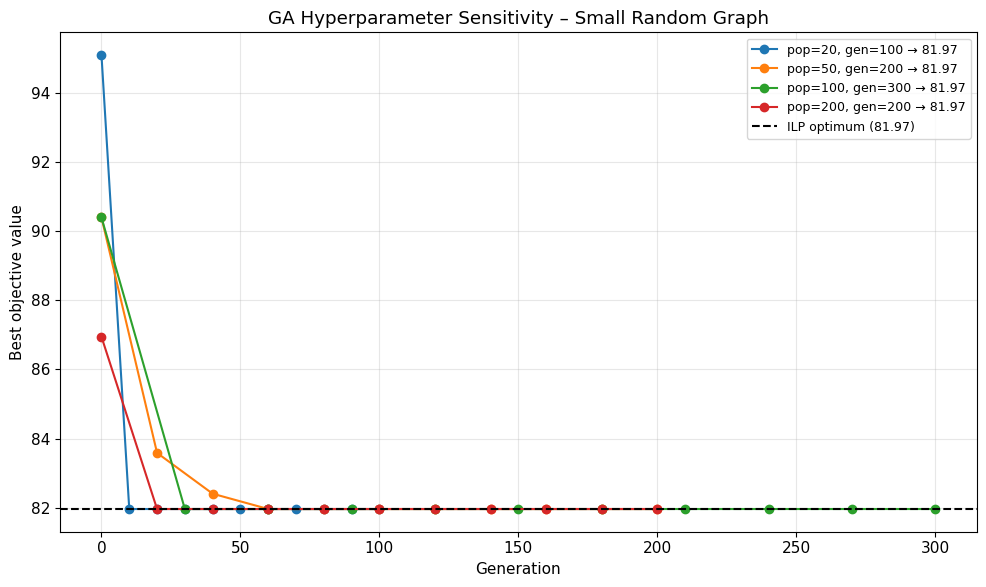

In [21]:
configs = [
    {'pop_size': 20,  'max_gen': 100, 'label': 'pop=20, gen=100'},
    {'pop_size': 50,  'max_gen': 200, 'label': 'pop=50, gen=200'},
    {'pop_size': 100, 'max_gen': 300, 'label': 'pop=100, gen=300'},
    {'pop_size': 200, 'max_gen': 200, 'label': 'pop=200, gen=200'},
]

fig, ax = plt.subplots(figsize=(10, 6))

for cfg in configs:
    _, _, cost, hist = genetic_algorithm_hflp(
        inst_small,
        pop_size=cfg['pop_size'],
        max_gen=cfg['max_gen'],
        seed=42, verbose=False
    )
    gens  = [h[0] for h in hist]
    bests = [h[1] for h in hist]
    ax.plot(gens, bests, marker='o', label=f"{cfg['label']} → {cost:.2f}")

ax.axhline(ilp_cost_s, color='black', lw=1.5, ls='--', label=f'ILP optimum ({ilp_cost_s:.2f})')
ax.set_xlabel('Generation')
ax.set_ylabel('Best objective value')
ax.set_title('GA Hyperparameter Sensitivity – Small Random Graph')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Summary Table

| Instance | Algorithm | Cost | Gap vs ILP | Time (s) |
|----------|-----------|------|-----------|----------|
| Small (n=20) | SA  | … | … | … |
| Small (n=20) | GA  | … | … | … |
| Small (n=20) | ILP | … | 0% | … |
| Medium (n=50) | SA  | … | … | … |
| Medium (n=50) | GA  | … | … | … |
| Medium (n=50) | ILP | … | — | … |
| Grid (n=400) | SA  | … | N/A | … |
| Grid (n=400) | GA  | … | N/A | … |

*Gaps computed against ILP best bound. N/A = ILP not run at this scale.*

In [22]:
def gap(cost, ref):
    if ref in (float('inf'), None):
        return 'N/A'
    return f'{100*(cost - ref)/ref:.2f}%'

rows = [
    ('Small (n=20)',  'SA',  sa_cost_s,  gap(sa_cost_s,  ilp_cost_s), sa_time_s),
    ('Small (n=20)',  'GA',  ga_cost_s,  gap(ga_cost_s,  ilp_cost_s), ga_time_s),
    ('Small (n=20)',  'ILP', ilp_cost_s, '0.00%',                     ilp_time_s),
    ('Medium (n=50)', 'SA',  sa_cost_m,  gap(sa_cost_m,  ilp_cost_m), sa_time_m),
    ('Medium (n=50)', 'GA',  ga_cost_m,  gap(ga_cost_m,  ilp_cost_m), ga_time_m),
    ('Medium (n=50)', 'ILP', ilp_cost_m, '—',                         ilp_time_m),
    ('Grid (n=400)',  'SA',  sa_cost_g,  'N/A',                       sa_time_g),
    ('Grid (n=400)',  'GA',  ga_cost_g,  'N/A',                       ga_time_g),
]

print(f'{"Instance":<18} {"Algo":<5} {"Cost":>12} {"Gap":>10} {"Time (s)":>10}')
print('-' * 60)
for inst_name, algo, cost, gapv, t in rows:
    print(f'{inst_name:<18} {algo:<5} {cost:>12.2f} {gapv:>10} {t:>10.2f}')

Instance           Algo          Cost        Gap   Time (s)
------------------------------------------------------------
Small (n=20)       SA           81.97      0.00%       0.25
Small (n=20)       GA           81.97      0.00%       0.85
Small (n=20)       ILP          81.97      0.00%       0.08
Medium (n=50)      SA          136.71      0.00%       2.03
Medium (n=50)      GA          136.71      0.00%       5.50
Medium (n=50)      ILP         136.71          —       0.27
Grid (n=400)       SA        24382.00        N/A       8.31
Grid (n=400)       GA        24006.00        N/A      35.20
